# Compute and save overturning $\psi, \bar{\psi}, \psi^\text{mean}$

$$
    \psi_n = -\sum_{i=n+1}^N h_i \mathbf{u}_i, \qquad n=0,\ldots,N-1
$$
Define $\psi_N=0$ and save $\psi$ on zi (interface) levels.

$$
    \bar{\psi}_n = -\sum_{i=n+1}^N \overline{h_i \mathbf{u}_i}, \qquad n=0,\ldots,N-1
$$

$$
    \psi_n^\text{mean} = -\sum_{i=n+1}^N \bar{h}_i \bar{\mathbf{u}}_i, \qquad n=0,\ldots,N-1
$$

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from xgcm import Grid
from dask.diagnostics import ProgressBar
import matplotlib.pylab as pylab
import filter

In [2]:
#deg = 8
#filter_fac = 4
#N = 8
#exp = '1/8 deg --> 1/2 deg'

deg = 16
filter_fac = 8
N = 15
exp = '1/16 deg --> 1/2 deg'

end_time = 32500
shape = 'Gaussian'
doEff = 1

## Open filtered Neverworld2 model data

In [26]:
if deg == 4:
    run = 20
    chunks = {'time': 50} 
    nr_days = 500
elif deg == 8:
    run = 26 
    chunks = {'time': 20} 
    nr_days = 500
elif deg == 16:
    run = 28 
    chunks = {'time': 5}
    nr_days = 500
      
st = xr.open_dataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/static.nc' % (run), decode_times=False)
av = xr.open_dataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/averages_000%i.nc' % (run,end_time-500+2), 
                     decode_times=False,chunks=chunks)
sn = xr.open_dataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/snapshots_000%i.nc' % (run, end_time-nr_days+5),
                         decode_times=False,chunks=chunks)

if doEff:
    strEff = 'eff'
else:
    strEff = 'raw'
    
import os.path
from os import path
av_ffile_f = '/glade/scratch/noraloose/filtered_data/run%i/averages_000%i_filtered_%s%i_fac%s%i.nc' %(run, 
                                                                        end_time-500+2,shape,N,strEff,filter_fac)
if path.exists(av_ffile_f):
    av_f = xr.open_dataset(av_ffile_f,decode_times=False,chunks=chunks)
    av_f_missing = 0
else:
    av_f_missing = 1
    av_f = xr.Dataset() # new xarray dataset for filtered h,u,v
    av_f.attrs['filter_specs'] = '(shape, N, factor, effective < raw, degree high-res run) = (%s, %i, %i, %s, %i)' %(shape,
                                                                                            N,filter_fac,strEff,deg)
    for fld in av.dims:
        av_f[fld] = av[fld]

### Make new datasets for $\psi,\bar{\psi}$

In [27]:
ds = xr.Dataset() # new xarray dataset for eta
ds_f = xr.Dataset() # new xarray dataset for filtered eta 
ds_f.attrs['filter_specs'] = '(shape, N, factor, effective < raw, degree high-res run) = (%s, %i, %i, %s, %i)' %(shape,
                                                                                            N,filter_fac,strEff,deg)

ffile = '/glade/work/noraloose/run%i/psi_averages_000%i.nc' % (run,end_time-500+2)
                                                                
psi_ffile_f = '/glade/scratch/noraloose/filtered_data/run%i/psi_averages_000%i_filtered_%s%i_fac%s%i.nc' %(run, 
                                                                        end_time-500+2,shape,N,strEff,filter_fac) 


In [28]:
for fld in av.dims:
    ds[fld] = av[fld]
    ds_f[fld] = av[fld]

## Prepare NW2 grid information

In [29]:
Nx = np.size(st.xh)
Ny = np.size(st.yh)

coords = {'X': {'center': 'xh', 'outer': 'xq'},
            'Y': {'center': 'yh', 'outer': 'yq'},
            'Z': {'center': 'zl', 'outer': 'zi'} }
metrics = {('X',):['dxCu','dxCv','dxT','dxBu'],
           ('Y',):['dyCu','dyCv','dyT','dyBu']
          }

grid = Grid(st, coords=coords, periodic=['X'])

st['dxT'] = grid.interp(st.dxCu,'X')
st['dyT'] = grid.interp(st.dyCv,'Y')
st['dxBu'] = grid.interp(st.dxCv,'X')
st['dyBu'] = grid.interp(st.dyCu,'Y',boundary='fill')

grid = Grid(st, coords=coords, periodic=['X'], metrics=metrics)


## Define filter

# Laplacian steps: 13; # Biharmonic steps: 1


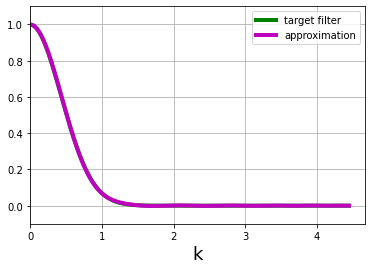

In [30]:
if doEff:
    Lf = filter_fac/np.sqrt(6)
else:
    Lf = filter_fac
    
NL, sL, NB, sB = filter.filterSpec(N, 1, Lf, shape)
print('# Laplacian steps: ' + str(NL) + '; # Biharmonic steps: ' + str(NB))

In [31]:
try:
    from cupy import get_array_module as _get_array_module
except ImportError:
    import numpy as np

    def _get_array_module(*args):
        return np

In [32]:
def simple_Laplacian(phi,wetMask):
    xp = _get_array_module(phi)
    """Laplacian for regular grid.
    
    Parameters
    ----------
    phi : array_like
    wetMask: array_like, same dimensions as phi
    
    Returns
    -------
    array_like
        Laplacian of `phi`
    """
    out = phi.copy()
    out = xp.nan_to_num(out) 
    out = wetMask * out 
    
    fac = (xp.roll(wetMask, -1, axis=-1) 
            + xp.roll(wetMask, 1, axis=-1) 
            + xp.roll(wetMask, -1, axis=-2) 
            + xp.roll(wetMask, 1, axis=-2)  
    )
        
    out = (- fac * out
            + xp.roll(out, -1, axis=-1) 
            + xp.roll(out, 1, axis=-1) 
            + xp.roll(out, -1, axis=-2) 
            + xp.roll(out, 1, axis=-2)
    )
        
    out = wetMask * out
    return out

In [33]:
def applyFilter(field,wetMask):
    xp = _get_array_module(field)
    """
    Filters a 2D field, applying an operator of type (*) above. 
    Assumes dx = dy = 1
    
    Inputs:
    field: 2D array (y, x) to be filtered
    wetMask: 2D array, same size as field: 0 if cell is land, 1 if it is wet.
    
    Output:
    Filtered field.
    """
    fieldBar = field.copy()
    fieldBar = xp.nan_to_num(fieldBar) 
    fieldBar = fieldBar * wetMask # Initalize the filtering process
    for i in range(NL):
        tempL = simple_Laplacian(fieldBar,wetMask) # Compute Laplacian
        fieldBar = fieldBar + (1/sL[i])*tempL # Update filtered field
    for i in range(NB): 
        tempL = simple_Laplacian(fieldBar,wetMask) # Compute Laplacian
        tempB = simple_Laplacian(tempL,wetMask) # Compute Biharmonic
        fieldBar = fieldBar + (2*np.real(sB[i])/np.abs(sB[i])**2)*tempL + (1/np.abs(sB[i])**2)*tempB
        
    return fieldBar

In [34]:
if av_f_missing: #filter h, u, v
    fldlist = ['h']

    dims = ['yh', 'xh']
    wetMask = st.wet.copy()

    for fld in fldlist:   
        dataBar = av[fld].copy() # Initialize the filtering process
        dataBar = dataBar * st.area_t # multiply by cell area

        dataBar = xr.apply_ufunc(applyFilter,
                            dataBar, wetMask,
                            input_core_dims=[dims,dims],
                            output_core_dims=[dims],
                            output_dtypes=[dataBar.dtype],
                            dask='parallelized'
        )
  
        dataBar = xr.where(st.wet,dataBar,np.nan) # mask by nan's if on land
        dataBar = dataBar/st.area_t # divide by cell area   
    

        dataBar = dataBar.transpose('time', 'zl', 'yh', 'xh') # reorder coordinates
            
        av_f[fld] = dataBar.copy()
    
    fldlist = ['psiu']

    fldlist = ['u']
    dims = ['yh', 'xq']
    wetMask = st.wet_u.isel(xq=slice(0,Nx)).copy() # disregard last slice xq=Nx (coincides with xq=0)

    for fld in fldlist:   
        dataBar = av[fld].isel(xq=slice(0,Nx)).copy() # Initialize the filtering process
        dataBar = dataBar * st.area_u.isel(xq=slice(0,Nx)) # multiply by cell area

        dataBar = xr.apply_ufunc(applyFilter,
                            dataBar, wetMask,
                            input_core_dims=[dims,dims],
                            output_core_dims=[dims],
                            output_dtypes=[dataBar.dtype],
                            dask='parallelized'
        )

        dataBar = xr.where(st.wet_u.isel(xq=slice(0,Nx)),dataBar,np.nan) # mask by nan's if on land
        dataBar = dataBar/st.area_u.isel(xq=slice(0,Nx)) # divide by cell area
    
        av_f[fld] = dataBar.copy()
        # append slice xq = 0 as xq = Nx:
        av_f[fld] = xr.where(av_f.xq==av_f.xq[-1],av_f[fld].roll(xq=-1,roll_coords=False),av_f[fld])
        av_f[fld] = av_f[fld].transpose('time', 'zl', 'yh', 'xq') # reorder coordinates
        #av_f[fld].attrs['long_name'] = 'Filtered ' + av[fld].attrs['long_name']

    fldlist = ['v']

    dims = ['yq', 'xh']
    wetMask = st.wet_v.copy()

    for fld in fldlist:   
        dataBar = av[fld].copy() # Initialize the filtering process
        dataBar = dataBar * st.area_v # multiply by cell area
        
        dataBar = xr.apply_ufunc(applyFilter,
                            dataBar, wetMask,
                            input_core_dims=[dims,dims],
                            output_core_dims=[dims],
                            output_dtypes=[dataBar.dtype],
                            dask='parallelized'
        )


        dataBar = xr.where(st.wet_v,dataBar,np.nan) # mask by nan's if on land
        dataBar = dataBar/st.area_v # divide by cell area
        dataBar = dataBar.transpose('time', 'zl', 'yq', 'xh') # reorder coordinates
    
        av_f[fld] = dataBar.copy()

/glade/u/apps/dav/opt/python/3.7.9/gnu/9.1.0/pkg-library/20201220/lib/python3.7/site-packages/xarray/core/indexing.py:1369: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


## Compute psi
\begin{align*}
    \psi_k & = - \sum_{i=k+1}^N h_i u_i
\end{align*}

\begin{align*}
    \psi^\text{mean}_k & = - \sum_{i=k+1}^N \bar{h}_i \bar{u}_i
\end{align*}

In [43]:
psiu = (av['uh']/st['dyCu']).isel(zl=slice(None,None,-1))
psiu = grid.cumsum(psiu,'Z',boundary='fill')
psiu = - psiu.isel(zi=slice(None,None,-1))
psiu = psiu.chunk({'zi':16})
psiu = xr.where(st.wet_u,psiu,np.nan)
psiu = psiu.transpose('time', 'zi', 'yh', 'xq') # reorder coordinates
ds['psiu'] = psiu.copy()
ds['psiu'].attrs['long_name'] = 'overturning in x-direction'

psiv = (av['vh']/st['dxCv']).isel(zl=slice(None,None,-1))
psiv = grid.cumsum(psiv,'Z',boundary='fill')
psiv = - psiv.isel(zi=slice(None,None,-1))
psiv = psiv.chunk({'zi':16})
psiv = xr.where(st.wet_v,psiv,np.nan)
psiv = psiv.transpose('time', 'zi', 'yq', 'xh') # reorder coordinates
ds['psiv'] = psiv.copy()
ds['psiv'].attrs['long_name'] = 'overturning in y-direction'

psiu_mean = (av_f['u'] * grid.interp(av_f['h'],'X',metric_weighted=['X','Y'])).isel(zl=slice(None,None,-1))
psiu_mean = grid.cumsum(psiu_mean,'Z',boundary='fill')
psiu_mean = - psiu_mean.isel(zi=slice(None,None,-1))
psiu_mean = psiu_mean.chunk({'zi':16,'xq':Nx+1})
psiu_mean = xr.where(st.wet_u,psiu_mean,np.nan)
psiu_mean = psiu_mean.transpose('time', 'zi', 'yh', 'xq') # reorder coordinates
ds_f['psiu_mean'] = psiu_mean.copy()
ds_f['psiu_mean'].attrs['long_name'] = 'mean overturning in x-direction'

psiv_mean = (av_f['v'] * grid.interp(av_f['h'],'Y',boundary='fill',metric_weighted=['X','Y'])).isel(zl=slice(None,None,-1))
psiv_mean = grid.cumsum(psiv_mean,'Z',boundary='fill')
psiv_mean = - psiv_mean.isel(zi=slice(None,None,-1))
psiv_mean = psiv_mean.chunk({'zi':16,'yq':Ny+1})
psiv_mean = xr.where(st.wet_v,psiv_mean,np.nan)
psiv_mean = psiv_mean.transpose('time', 'zi', 'yq', 'xh') # reorder coordinates
ds_f['psiv_mean'] = psiv_mean.copy()
ds_f['psiv_mean'].attrs['long_name'] = 'mean overturning in y-direction'

### $\psi$

[Text(0.5, 1.0, '$\\psi_{15} = 0$: v-component')]

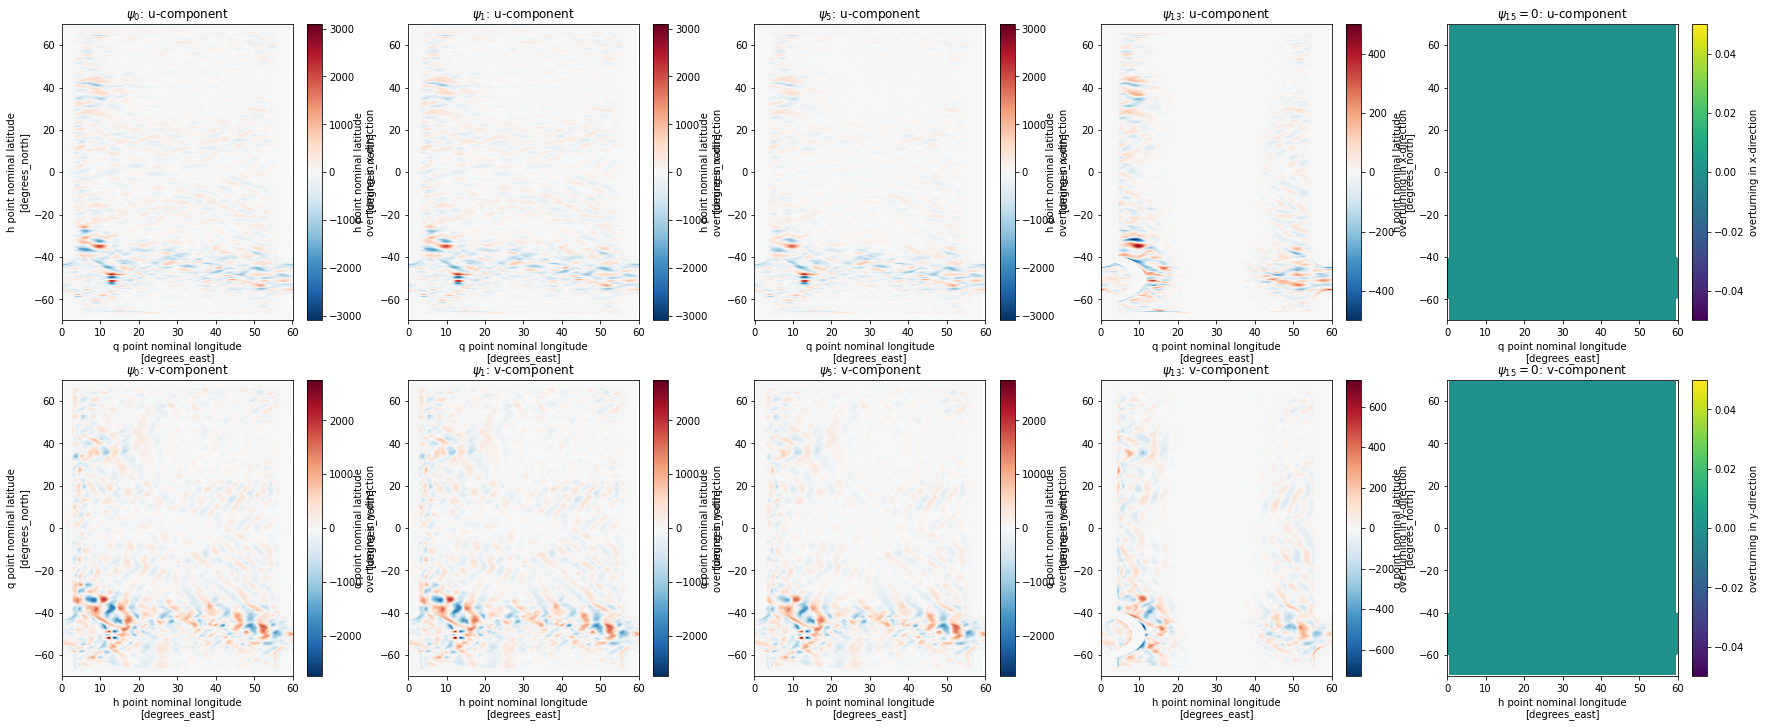

In [44]:
time = 10
fig,axs = plt.subplots(2,5,figsize=(30,12))

ds.psiu.isel(time=time,zi=0).plot(ax=axs[0,0])
axs[0,0].set(title = r'$\psi_0$: u-component')
ds.psiu.isel(time=time,zi=1).plot(ax=axs[0,1])
axs[0,1].set(title=r'$\psi_1$: u-component')
ds.psiu.isel(time=time,zi=5).plot(ax=axs[0,2])
axs[0,2].set(title=r'$\psi_5$: u-component')
ds.psiu.isel(time=time,zi=13).plot(ax=axs[0,3])
axs[0,3].set(title=r'$\psi_{13}$: u-component')
ds.psiu.isel(time=time,zi=15).plot(ax=axs[0,4])
axs[0,4].set(title=r'$\psi_{15} = 0$: u-component')

ds.psiv.isel(time=time,zi=0).plot(ax=axs[1,0])
axs[1,0].set(title = r'$\psi_0$: v-component')
ds.psiv.isel(time=time,zi=1).plot(ax=axs[1,1])
axs[1,1].set(title=r'$\psi_1$: v-component')
ds.psiv.isel(time=time,zi=5).plot(ax=axs[1,2])
axs[1,2].set(title=r'$\psi_5$: v-component')
ds.psiv.isel(time=time,zi=13).plot(ax=axs[1,3])
axs[1,3].set(title=r'$\psi_{13}$: v-component')
ds.psiv.isel(time=time,zi=15).plot(ax=axs[1,4])
axs[1,4].set(title=r'$\psi_{15} = 0$: v-component')

### $\psi^\text{mean}$

[Text(0.5, 1.0, '$\\psi_{15} = 0$: mean v-component')]

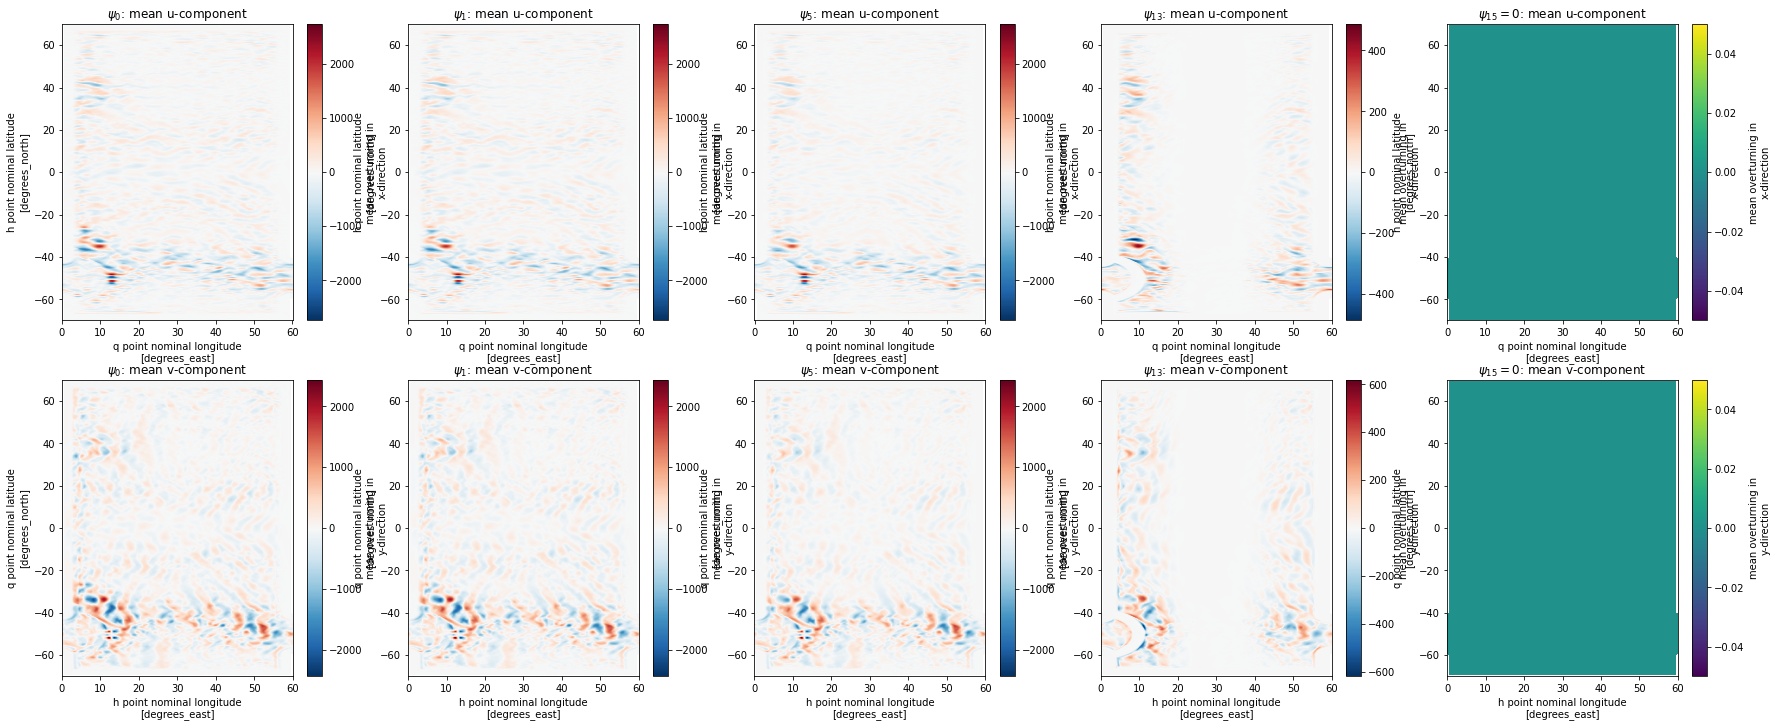

In [46]:
time = 10
fig,axs = plt.subplots(2,5,figsize=(30,12))

ds_f.psiu_mean.isel(time=time,zi=0).plot(ax=axs[0,0])
axs[0,0].set(title = r'$\psi_0$: mean u-component')
ds_f.psiu_mean.isel(time=time,zi=1).plot(ax=axs[0,1])
axs[0,1].set(title=r'$\psi_1$: mean u-component')
ds_f.psiu_mean.isel(time=time,zi=5).plot(ax=axs[0,2])
axs[0,2].set(title=r'$\psi_5$: mean u-component')
ds_f.psiu_mean.isel(time=time,zi=13).plot(ax=axs[0,3])
axs[0,3].set(title=r'$\psi_{13}$: mean u-component')
ds_f.psiu_mean.isel(time=time,zi=15).plot(ax=axs[0,4])
axs[0,4].set(title=r'$\psi_{15} = 0$: mean u-component')

ds_f.psiv_mean.isel(time=time,zi=0).plot(ax=axs[1,0])
axs[1,0].set(title = r'$\psi_0$: mean v-component')
ds_f.psiv_mean.isel(time=time,zi=1).plot(ax=axs[1,1])
axs[1,1].set(title=r'$\psi_1$: mean v-component')
ds_f.psiv_mean.isel(time=time,zi=5).plot(ax=axs[1,2])
axs[1,2].set(title=r'$\psi_5$: mean v-component')
ds_f.psiv_mean.isel(time=time,zi=13).plot(ax=axs[1,3])
axs[1,3].set(title=r'$\psi_{13}$: mean v-component')
ds_f.psiv_mean.isel(time=time,zi=15).plot(ax=axs[1,4])
axs[1,4].set(title=r'$\psi_{15} = 0$: mean v-component')

# Filter $\psi$

### U fields

In [50]:
fldlist = ['psiu']

dims = ['yh', 'xq']
wetMask = st.wet_u.isel(xq=slice(0,Nx)).copy() # disregard last slice xq=Nx (coincides with xq=0)

for fld in fldlist:   
    dataBar = ds[fld].isel(xq=slice(0,Nx)).copy() # Initialize the filtering process
    dataBar = dataBar * st.area_u.isel(xq=slice(0,Nx)) # multiply by cell area

    dataBar = xr.apply_ufunc(applyFilter,
                            dataBar, wetMask,
                            input_core_dims=[dims,dims],
                            output_core_dims=[dims],
                            output_dtypes=[dataBar.dtype],
                            dask='parallelized'
    )

    dataBar = xr.where(st.wet_u.isel(xq=slice(0,Nx)),dataBar,np.nan) # mask by nan's if on land
    dataBar = dataBar/st.area_u.isel(xq=slice(0,Nx)) # divide by cell area
    
    ds_f[fld] = dataBar.copy()
    # append slice xq = 0 as xq = Nx:
    ds_f[fld] = xr.where(ds_f.xq==ds_f.xq[-1],ds_f[fld].roll(xq=-1,roll_coords=False),ds_f[fld])
    ds_f[fld] = ds_f[fld].transpose('time', 'zi', 'yh', 'xq') # reorder coordinates
    #av_f[fld].attrs['long_name'] = 'Filtered ' + av[fld].attrs['long_name']

/glade/u/apps/dav/opt/python/3.7.9/gnu/9.1.0/pkg-library/20201220/lib/python3.7/site-packages/xarray/core/indexing.py:1369: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


### V fields

In [51]:
fldlist = ['psiv']

dims = ['yq', 'xh']
wetMask = st.wet_v.copy()

for fld in fldlist:   
    dataBar = ds[fld].copy() # Initialize the filtering process
    dataBar = dataBar * st.area_v # multiply by cell area
        
    dataBar = xr.apply_ufunc(applyFilter,
                            dataBar, wetMask,
                            input_core_dims=[dims,dims],
                            output_core_dims=[dims],
                            output_dtypes=[dataBar.dtype],
                            dask='parallelized'
    )


    dataBar = xr.where(st.wet_v,dataBar,np.nan) # mask by nan's if on land
    dataBar = dataBar/st.area_v # divide by cell area
    dataBar = dataBar.transpose('time', 'zi', 'yq', 'xh') # reorder coordinates
    
    ds_f[fld] = dataBar.copy()
    #av_f[fld].attrs = av[fld].attrs
    #av_f[fld].attrs['long_name'] = 'Filtered ' + av[fld].attrs['long_name']

## Plot unfiltered vs. filtered fields

[Text(0.5, 1.0, '$\\overline{\\psi_{15}} = 0$: v-component')]

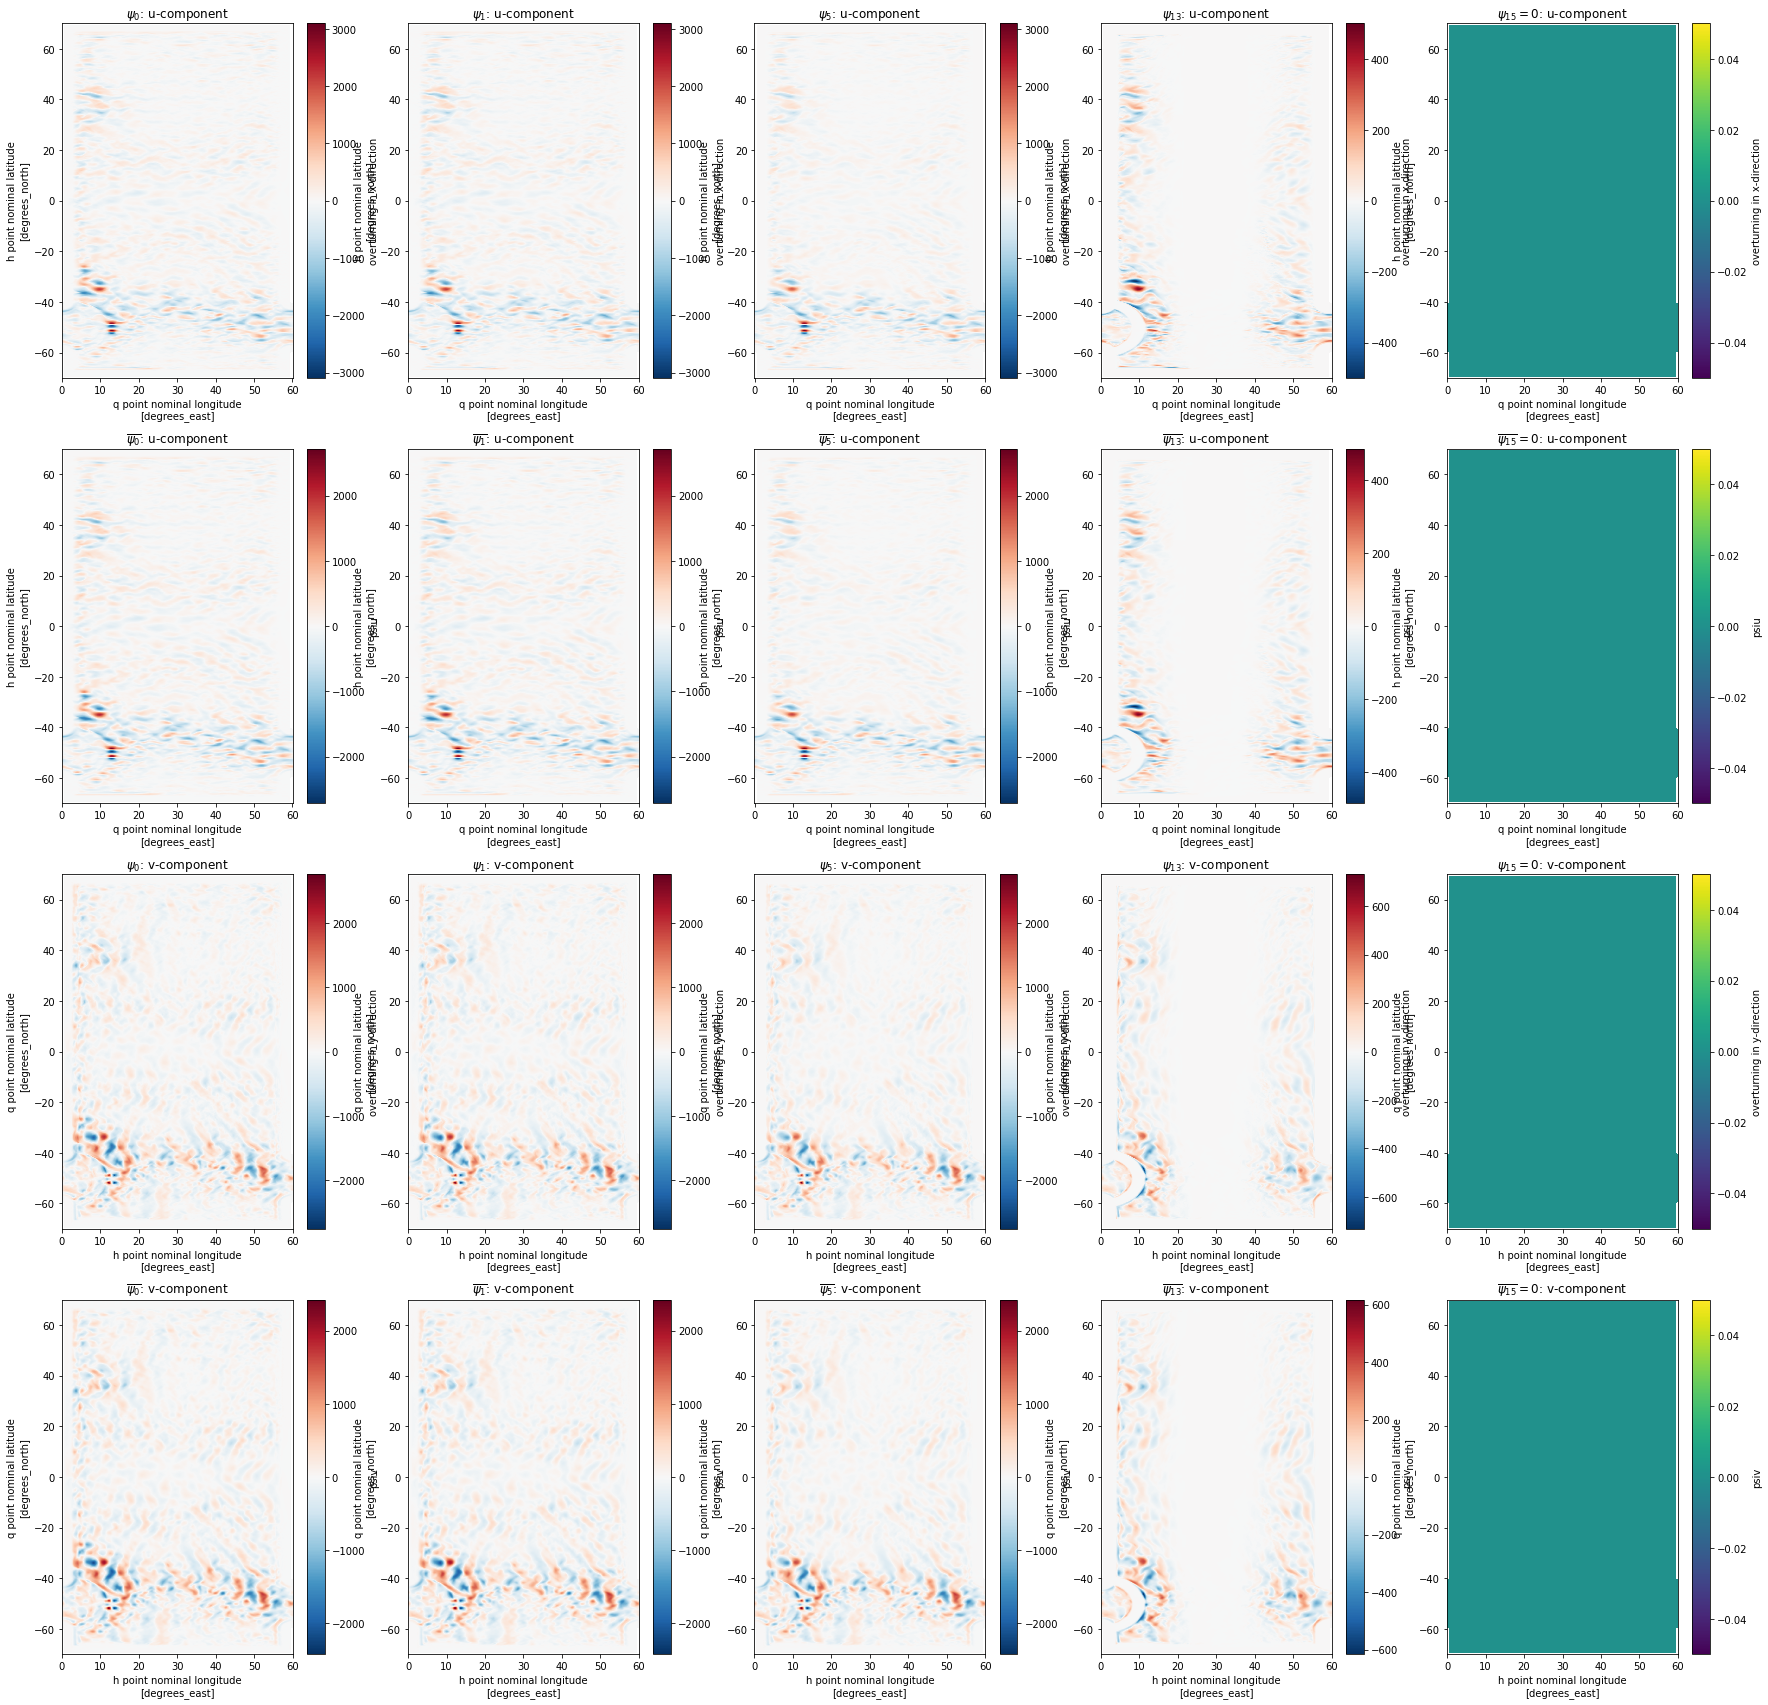

In [52]:
time = 10
fig,axs = plt.subplots(4,5,figsize=(30,30))

ds.psiu.isel(time=time,zi=0).plot(ax=axs[0,0])
axs[0,0].set(title = r'$\psi_0$: u-component')
ds.psiu.isel(time=time,zi=1).plot(ax=axs[0,1])
axs[0,1].set(title=r'$\psi_1$: u-component')
ds.psiu.isel(time=time,zi=5).plot(ax=axs[0,2])
axs[0,2].set(title=r'$\psi_5$: u-component')
ds.psiu.isel(time=time,zi=13).plot(ax=axs[0,3])
axs[0,3].set(title=r'$\psi_{13}$: u-component')
ds.psiu.isel(time=time,zi=15).plot(ax=axs[0,4])
axs[0,4].set(title=r'$\psi_{15} = 0$: u-component')

ds_f.psiu.isel(time=time,zi=0).plot(ax=axs[1,0])
axs[1,0].set(title = r'$\overline{\psi_0}$: u-component')
ds_f.psiu.isel(time=time,zi=1).plot(ax=axs[1,1])
axs[1,1].set(title=r'$\overline{\psi_1}$: u-component')
ds_f.psiu.isel(time=time,zi=5).plot(ax=axs[1,2])
axs[1,2].set(title=r'$\overline{\psi_5}$: u-component')
ds_f.psiu.isel(time=time,zi=13).plot(ax=axs[1,3])
axs[1,3].set(title=r'$\overline{\psi_{13}}$: u-component')
ds_f.psiu.isel(time=time,zi=15).plot(ax=axs[1,4])
axs[1,4].set(title=r'$\overline{\psi_{15}} = 0$: u-component')

ds.psiv.isel(time=time,zi=0).plot(ax=axs[2,0])
axs[2,0].set(title = r'$\psi_0$: v-component')
ds.psiv.isel(time=time,zi=1).plot(ax=axs[2,1])
axs[2,1].set(title=r'$\psi_1$: v-component')
ds.psiv.isel(time=time,zi=5).plot(ax=axs[2,2])
axs[2,2].set(title=r'$\psi_5$: v-component')
ds.psiv.isel(time=time,zi=13).plot(ax=axs[2,3])
axs[2,3].set(title=r'$\psi_{13}$: v-component')
ds.psiv.isel(time=time,zi=15).plot(ax=axs[2,4])
axs[2,4].set(title=r'$\psi_{15} = 0$: v-component')

ds_f.psiv.isel(time=time,zi=0).plot(ax=axs[3,0])
axs[3,0].set(title = r'$\overline{\psi_0}$: v-component')
ds_f.psiv.isel(time=time,zi=1).plot(ax=axs[3,1])
axs[3,1].set(title=r'$\overline{\psi_1}$: v-component')
ds_f.psiv.isel(time=time,zi=5).plot(ax=axs[3,2])
axs[3,2].set(title=r'$\overline{\psi_5}$: v-component')
ds_f.psiv.isel(time=time,zi=13).plot(ax=axs[3,3])
axs[3,3].set(title=r'$\overline{\psi_{13}}$: v-component')
ds_f.psiv.isel(time=time,zi=15).plot(ax=axs[3,4])
axs[3,4].set(title=r'$\overline{\psi_{15}} = 0$: v-component')

## Save to netcdf

In [20]:
ffile = '/glade/work/noraloose/run%i/psi_averages_000%i.nc' % (run,end_time-500+2)
                                                                
psi_ffile_f = '/glade/scratch/noraloose/filtered_data/run%i/psi_averages_000%i_filtered_%s%i_fac%s%i.nc' %(run, 
                                                                        end_time-500+2,shape,N,strEff,filter_fac) 

In [21]:
ds.to_netcdf(ffile)
ds_f.to_netcdf(psi_ffile_f)